### Trabalho 1 - MIneração de dados
O objetivo deste exercício é explorar, tratar e visualizar dados públicos do Brasil disponibilizados pelo IBGE, aplicando técnicas de mineração de dados e construção de gráficos estatísticos.

Os datasets escolhidos foram: 
- PIB dos Municípios – dados econômicos por cidade.
- SIDRA (Sistema IBGE de Recuperação Automática)

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

caminho1 = Path("datas/PIBMunicipios.csv")
caminho2 = Path("datas/tabela_ensino.xlsx")
caminho3 = Path("datas/projecoes_2024.xlsx")

df_pib = pd.read_csv(caminho1, sep=';', skiprows=1, nrows=1, encoding='utf-8')
df_educacao = pd.read_excel(caminho2, skiprows=4)
df_populacao = pd.read_excel(caminho3, skiprows=5, index_col=0)

In [130]:
print("Quantidade de linhas e colunas:", df_populacao.shape)

df_populacao.info()

print('Quantidade de duplicatas: ', df_populacao.duplicated().sum())

Quantidade de linhas e colunas: (9009, 75)
<class 'pandas.DataFrame'>
Index: 9009 entries, 0 to 90
Data columns (total 75 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   SEXO    9009 non-null   str  
 1   CÓD.    9009 non-null   int64
 2   SIGLA   9009 non-null   str  
 3   LOCAL   9009 non-null   str  
 4   2000    9009 non-null   int64
 5   2001    9009 non-null   int64
 6   2002    9009 non-null   int64
 7   2003    9009 non-null   int64
 8   2004    9009 non-null   int64
 9   2005    9009 non-null   int64
 10  2006    9009 non-null   int64
 11  2007    9009 non-null   int64
 12  2008    9009 non-null   int64
 13  2009    9009 non-null   int64
 14  2010    9009 non-null   int64
 15  2011    9009 non-null   int64
 16  2012    9009 non-null   int64
 17  2013    9009 non-null   int64
 18  2014    9009 non-null   int64
 19  2015    9009 non-null   int64
 20  2016    9009 non-null   int64
 21  2017    9009 non-null   int64
 22  2018    9009 non-null  

In [131]:
print("Quantidade de linhas e colunas:", df_pib.shape)

df_pib.info()

print('Quantidade de duplicatas:', df_pib.duplicated().sum())

Quantidade de linhas e colunas: (1, 27)
<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Acre                 1 non-null      int64
 1   Alagoas              1 non-null      int64
 2   Amapá                1 non-null      int64
 3   Amazonas             1 non-null      int64
 4   Bahia                1 non-null      int64
 5   Ceará                1 non-null      int64
 6   Distrito Federal     1 non-null      int64
 7   Espírito Santo       1 non-null      int64
 8   Goiás                1 non-null      int64
 9   Maranhão             1 non-null      int64
 10  Mato Grosso          1 non-null      int64
 11  Mato Grosso do Sul   1 non-null      int64
 12  Minas Gerais         1 non-null      int64
 13  Paraná               1 non-null      int64
 14  Paraíba              1 non-null      int64
 15  Pará                 1 non-null      int64
 16  P

In [132]:
print("Quantidade de linhas e colunas:", df_educacao.shape)

df_educacao.info()

print('Quantidade de duplicatas:', df_educacao.duplicated().sum())

Quantidade de linhas e colunas: (28, 5)
<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Unnamed: 0                                 28 non-null     str    
 1   Ensino superior completo ou equivalente    27 non-null     float64
 2   Ensino superior completo ou equivalente.1  27 non-null     float64
 3   Ensino superior completo ou equivalente.2  27 non-null     float64
 4   Ensino superior completo ou equivalente.3  27 non-null     float64
dtypes: float64(4), str(1)
memory usage: 1.2 KB
Quantidade de duplicatas: 0


<p align='center'> TRATAMENTO DE DADOS </p>

<p align='center'> Funções </p>

In [133]:
def formato_brl(valor):
    return f'R$ {valor:,.2f}'

<p align='center'> População </p>

In [134]:
df_populacao = df_populacao[['SEXO','LOCAL', 2023]]

df_populacao_por_uf = df_populacao[df_populacao['SEXO'] == 'Ambos']

df_populacao_por_uf = df_populacao_por_uf[['LOCAL', 2023]].groupby('LOCAL').sum()

df_populacao_por_uf.index.name = None

df_populacao_por_uf = df_populacao_por_uf.drop(index=['Brasil', 'Norte', 'Nordeste', 'Sul', 'Sudeste', 'Centro-Oeste'])

df_populacao_por_uf.columns = ['populacao em 2023']

display(df_populacao_por_uf)


,populacao em 2023
Acre,876582
Alagoas,3218607
Amapá,799124
Amazonas,4240571
Bahia,14828806
Ceará,9196672
Distrito Federal,2967543
Espírito Santo,4076068
Goiás,7274463
Maranhão,7003234


<p align='center'> PIB </p>

In [135]:
df_pib_copy = df_pib.copy()

df_pib_copy = df_pib_copy.T

df_pib_copy.columns = ['pib_mil_reais']

#df_pib_copy['pib_bilhoes'] = df_pib_copy['pib'] / 1_000_000

df_pib_copy = df_pib_copy.sort_values(by='pib_mil_reais', ascending= False)

display(df_pib_copy)

,pib_mil_reais
São Paulo,3444814033
Rio de Janeiro,1172871443
Minas Gerais,971977551
Paraná,670919162
Rio Grande do Sul,650107022
Santa Catarina,513392973
Bahia,430987853
Distrito Federal,365669108
Goiás,336746975
Mato Grosso,273008586


<p align='center'> PIB per capita </p>

In [136]:
df_pib_capita = df_pib_copy.join(df_populacao_por_uf)

df_pib_capita['pib_per_capita'] = (df_pib_capita['pib_mil_reais'] * 1000) / (df_pib_capita['populacao em 2023'])

display(df_pib_capita)

,pib_mil_reais,populacao em 2023,pib_per_capita
São Paulo,3444814033,45850570,75131.324060
Rio de Janeiro,1172871443,17213813,68135.481837
Minas Gerais,971977551,21247401,45745.715017
Paraná,670919162,11753862,57080.741802
Rio Grande do Sul,650107022,11222292,57929.968495
Santa Catarina,513392973,7927212,64763.371157
Bahia,430987853,14828806,29064.231672
Distrito Federal,365669108,2967543,123222.850688
Goiás,336746975,7274463,46291.660979
Mato Grosso,273008586,3778389,72255.288166


<p align='center'> Educação </p>

In [137]:
df_educacao_copy = df_educacao.set_index(df_educacao.columns[0])

df_educacao_copy.index.name = None

df_educacao_copy = (df_educacao_copy.mean(axis=1).dropna().to_frame('percentual superior completo (%)'))

df_educacao_copy = df_educacao_copy.sort_values(by='percentual superior completo (%)', ascending=False)

display(df_educacao_copy)

,percentual superior completo (%)
Distrito Federal,28.325
São Paulo,18.950
Rio de Janeiro,18.800
Mato Grosso do Sul,16.300
Santa Catarina,15.700
Amapá,15.525
Paraná,15.325
Rio Grande do Sul,14.600
Goiás,14.350
Espírito Santo,14.300


<p align="center">Educação + PIB per capita</p>

In [ ]:
df_educacao_pib_capita = df_pib_capita.join(df_educacao_copy)

df_educacao_pib_capita = df_educacao_pib_capita[['pib_per_capita', 'percentual superior completo (%)']]

display(df_educacao_pib_capita)

,pib_per_capita,percentual superior completo (%)
São Paulo,75131.324060,18.950
Rio de Janeiro,68135.481837,18.800
Minas Gerais,45745.715017,13.225
Paraná,57080.741802,15.325
Rio Grande do Sul,57929.968495,14.600
Santa Catarina,64763.371157,15.700
Bahia,29064.231672,8.525
Distrito Federal,123222.850688,28.325
Goiás,46291.660979,14.350
Mato Grosso,72255.288166,13.450


<p align="center">Análise exploratória</p>

In [ ]:
df_educacao_pib_capita.describe()

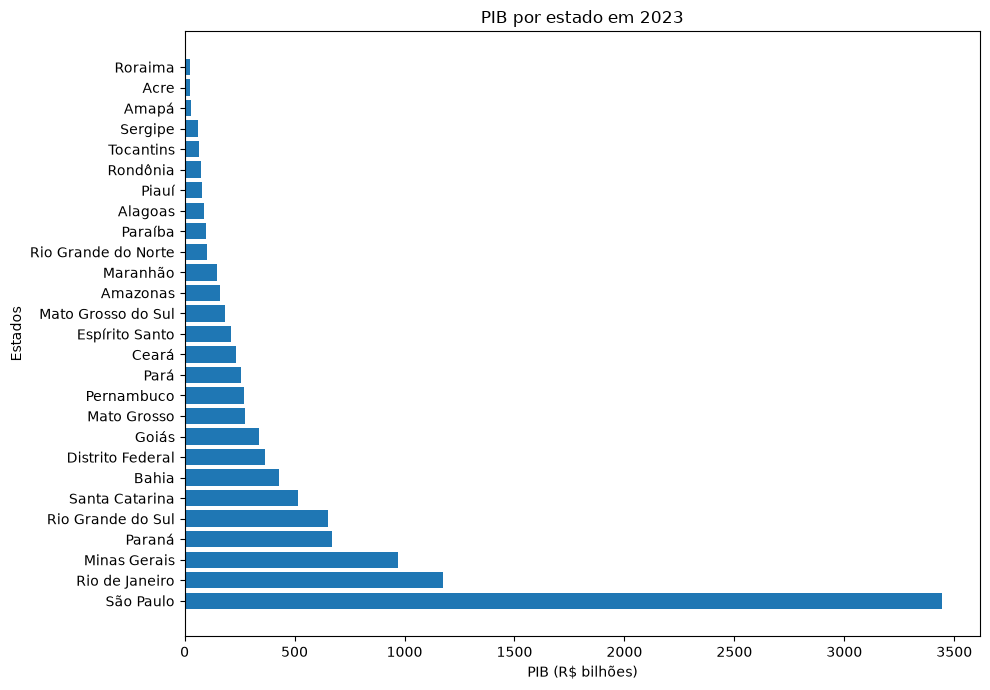

In [147]:
fig, ax = plt.subplots(figsize=(10, 7))

pib_bilhoes = df_pib_capita['pib_mil_reais'] / 1_000_000

ax.barh(df_pib_capita.index, pib_bilhoes)
ax.set_title('PIB por estado em 2023')
ax.set_xlabel('PIB (R$ bilhões)')
ax.set_ylabel('Estados')

plt.tight_layout()
plt.show()